## DistilBERT Text-Only Classification Model

##  Environment Setup

This notebook implements a **DistilBERT-based text classification model** for fashion product categorization. The required libraries are installed and configured before loading the pretrained model to ensure compatibility with **TensorFlow 2.20** and **Hugging Face Transformers 4.47.1**.

The notebook also verifies GPU availability and imports the necessary components for tokenization, model construction, training, and evaluation.

In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install -q "transformers==4.47.1" "tf-keras"

In [3]:
import transformers
import tensorflow as tf

print("Transformers:", transformers.__version__)
print("TensorFlow:", tf.__version__)

from transformers import AutoTokenizer, TFAutoModel

print("TFAutoModel import successful")

Transformers: 4.47.1
TensorFlow: 2.20.0
TFAutoModel import successful


In [4]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, TFAutoModel

## Project Configuration

The project directories, dataset paths, pretrained model paths, and output locations are defined in this section. These configurations are used throughout the notebook to ensure consistent access to datasets, saved models, training histories, and evaluation results.

In [6]:
PROJECT_FOLDER = "/content/drive/MyDrive/fashion_multimodal_project"

TRAIN_PATH = os.path.join(PROJECT_FOLDER, "train.csv")
VAL_PATH = os.path.join(PROJECT_FOLDER, "val.csv")
TEST_PATH = os.path.join(PROJECT_FOLDER, "test.csv")
LABEL_ENCODER_PATH = os.path.join(PROJECT_FOLDER, "label_encoder.pkl")

## Load the Dataset

The training, validation, and test datasets are loaded from the project directory. The saved label encoder is also restored to ensure consistent label mapping across training, evaluation, and feature extraction.

In [7]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

with open(LABEL_ENCODER_PATH, "rb") as file:
    label_encoder = pickle.load(file)

NUM_CLASSES = len(label_encoder.classes_)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))
print("Number of classes:", NUM_CLASSES)

Training samples: 30814
Validation samples: 4402
Test samples: 8804
Number of classes: 90


In [8]:
for dataframe in [train_df, val_df, test_df]:
    dataframe["text"] = dataframe["text"].fillna("").astype(str)
    dataframe["label"] = dataframe["label"].astype("int32")

print("Missing train text:", train_df["text"].isna().sum())
print("Empty train text:", train_df["text"].str.strip().eq("").sum())

display(train_df[["text", "articleType", "label"]].head())

Missing train text: 0
Empty train text: 0


,text,articleType,label
0,Women Footwear Shoes Casual Shoes Off White Wi...,Casual Shoes,12
1,Men Accessories Belts Belts Brown Summer Casua...,Belts,4
2,Men Apparel Bottomwear Shorts Grey Summer Spor...,Shorts,68
3,Men Accessories Watches Watches Grey Winter Ca...,Watches,89
4,Men Accessories Socks Socks Red Fall Casual Ma...,Socks,70


## Tokenization

The leakage-controlled product descriptions are tokenized using the pretrained DistilBERT tokenizer. Each sequence is truncated or padded to a fixed maximum length before being converted into input IDs and attention masks for model training.

In [9]:
TEXT_MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 64

tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [10]:
sample_lengths = [
    len(tokenizer.encode(text, add_special_tokens=True))
    for text in train_df["text"].sample(
        min(5000, len(train_df)),
        random_state=42
    )
]

print("Median token length:", np.median(sample_lengths))
print("95th percentile:", np.percentile(sample_lengths, 95))
print("Maximum sampled length:", max(sample_lengths))

Median token length: 19.0
95th percentile: 24.0
Maximum sampled length: 37


In [11]:
def tokenize_texts(texts):
    return tokenizer(
        texts.tolist(),
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="np"
    )

In [12]:
train_encodings = tokenize_texts(train_df["text"])
val_encodings = tokenize_texts(val_df["text"])
test_encodings = tokenize_texts(test_df["text"])

print("Train input IDs:", train_encodings["input_ids"].shape)
print("Train attention masks:", train_encodings["attention_mask"].shape)

Train input IDs: (30814, 64)
Train attention masks: (30814, 64)


In [13]:
TEXT_BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

In [14]:
def create_text_dataset(encodings, labels, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            {
                "input_ids": encodings["input_ids"],
                "attention_mask": encodings["attention_mask"]
            },
            labels.astype("int32")
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(labels),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    return dataset.batch(TEXT_BATCH_SIZE).prefetch(AUTOTUNE)

In [15]:
train_text_ds = create_text_dataset(
    train_encodings,
    train_df["label"].values,
    training=True
)

val_text_ds = create_text_dataset(
    val_encodings,
    val_df["label"].values
)

test_text_ds = create_text_dataset(
    test_encodings,
    test_df["label"].values
)

In [16]:
sample_inputs, sample_labels = next(iter(train_text_ds))

print("Input IDs shape:", sample_inputs["input_ids"].shape)
print("Attention mask shape:", sample_inputs["attention_mask"].shape)
print("Labels shape:", sample_labels.shape)

Input IDs shape: (32, 64)
Attention mask shape: (32, 64)
Labels shape: (32,)


## DistilBERT Text-Only Classification Model

A pretrained DistilBERT model is used to extract contextual text features.  
The hidden representation of the first token is passed through dropout and dense layers to classify products into the 90 `articleType` categories.

In [17]:
import tf_keras as keras
from transformers import TFAutoModel

In [18]:
distilbert_backbone = TFAutoModel.from_pretrained(
    TEXT_MODEL_NAME
)

# Stage 1: freeze DistilBERT
distilbert_backbone.trainable = False

print("DistilBERT loaded successfully.")

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_transform.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


DistilBERT loaded successfully.


In [19]:
class DistilBERTClassifier(keras.Model):
    def __init__(self, transformer, num_classes):
        super().__init__()

        self.transformer = transformer

        self.dropout_1 = keras.layers.Dropout(0.3)

        self.text_embedding = keras.layers.Dense(
            256,
            activation="relu",
            name="text_embedding"
        )

        self.dropout_2 = keras.layers.Dropout(0.3)

        self.classifier = keras.layers.Dense(
            num_classes,
            activation="softmax",
            name="text_classifier"
        )

    def call(self, inputs, training=False):
        transformer_outputs = self.transformer(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            training=training
        )

        # Representation of the first token
        cls_embedding = transformer_outputs.last_hidden_state[:, 0, :]

        x = self.dropout_1(cls_embedding, training=training)
        x = self.text_embedding(x)
        x = self.dropout_2(x, training=training)

        return self.classifier(x)

In [20]:
text_model = DistilBERTClassifier(
    transformer=distilbert_backbone,
    num_classes=NUM_CLASSES
)

In [21]:
sample_inputs, sample_labels = next(iter(train_text_ds))

sample_predictions = text_model(
    sample_inputs,
    training=False
)

print("Prediction shape:", sample_predictions.shape)

Prediction shape: (32, 90)


In [22]:
text_model.summary()

Model: "distil_bert_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 tf_distil_bert_model (TFDi  multiple                  66362880  
 stilBertModel)                                                  
                                                                 
 dropout_19 (Dropout)        multiple                  0         
                                                                 
 text_embedding (Dense)      multiple                  196864    
                                                                 
 dropout_20 (Dropout)        multiple                  0         
                                                                 
 text_classifier (Dense)     multiple                  23130     
                                                                 
Total params: 66582874 (253.99 MB)
Trainable params: 219994 (859.35 KB)
Non-trainable params: 66362880 (253.15

In [23]:
text_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        ),
        keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)

In [24]:
TEXT_STAGE1_MODEL_PATH = os.path.join(
    PROJECT_FOLDER,
    "distilbert_text_stage1_best.weights.h5"
)

text_stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=TEXT_STAGE1_MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
]

## Stage 1 Training

The DistilBERT classification head is trained while keeping the pretrained transformer backbone frozen. Model checkpoints, early stopping, and learning rate scheduling are used to obtain the best-performing model based on the validation set.

In [25]:
history_text_stage1 = text_model.fit(
    train_text_ds,
    validation_data=val_text_ds,
    epochs=5,
    callbacks=text_stage1_callbacks
)

Epoch 1/5
963/963 [==============================] - ETA: 0s - loss: 1.2284 - accuracy: 0.7202 - top_5_accuracy: 0.8737
Epoch 1: val_accuracy improved from -inf to 0.92254, saving model to /content/drive/MyDrive/fashion_multimodal_project/distilbert_text_stage1_best.weights.h5


/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


963/963 [==============================] - 116s 102ms/step - loss: 1.2284 - accuracy: 0.7202 - top_5_accuracy: 0.8737 - val_loss: 0.2812 - val_accuracy: 0.9225 - val_top_5_accuracy: 0.9880 - lr: 0.0010
Epoch 2/5
963/963 [==============================] - ETA: 0s - loss: 0.3690 - accuracy: 0.8994 - top_5_accuracy: 0.9854
Epoch 2: val_accuracy improved from 0.92254 to 0.95797, saving model to /content/drive/MyDrive/fashion_multimodal_project/distilbert_text_stage1_best.weights.h5


963/963 [==============================] - 96s 100ms/step - loss: 0.3690 - accuracy: 0.8994 - top_5_accuracy: 0.9854 - val_loss: 0.1350 - val_accuracy: 0.9580 - val_top_5_accuracy: 0.9991 - lr: 0.0010
Epoch 3/5
963/963 [==============================] - ETA: 0s - loss: 0.2465 - accuracy: 0.9286 - top_5_accuracy: 0.9946
Epoch 3: val_accuracy improved from 0.95797 to 0.97115, saving model to /content/drive/MyDrive/fashion_multimodal_project/distilbert_text_stage1_best.weights.h5


963/963 [==============================] - 98s 102ms/step - loss: 0.2465 - accuracy: 0.9286 - top_5_accuracy: 0.9946 - val_loss: 0.0896 - val_accuracy: 0.9711 - val_top_5_accuracy: 1.0000 - lr: 0.0010
Epoch 4/5
963/963 [==============================] - ETA: 0s - loss: 0.1964 - accuracy: 0.9412 - top_5_accuracy: 0.9965
Epoch 4: val_accuracy improved from 0.97115 to 0.98296, saving model to /content/drive/MyDrive/fashion_multimodal_project/distilbert_text_stage1_best.weights.h5


963/963 [==============================] - 98s 102ms/step - loss: 0.1964 - accuracy: 0.9412 - top_5_accuracy: 0.9965 - val_loss: 0.0632 - val_accuracy: 0.9830 - val_top_5_accuracy: 1.0000 - lr: 0.0010
Epoch 5/5
963/963 [==============================] - ETA: 0s - loss: 0.1733 - accuracy: 0.9461 - top_5_accuracy: 0.9977
Epoch 5: val_accuracy did not improve from 0.98296
963/963 [==============================] - 97s 100ms/step - loss: 0.1733 - accuracy: 0.9461 - top_5_accuracy: 0.9977 - val_loss: 0.0541 - val_accuracy: 0.9807 - val_top_5_accuracy: 1.0000 - lr: 0.0010
Restoring model weights from the end of the best epoch: 5.


## Training Behaviour

The training and validation curves are examined to assess model convergence and identify potential overfitting during Stage 1 training.

Accuracy, loss, and Top-5 accuracy are tracked across epochs to evaluate how well the frozen DistilBERT backbone and classification head learn from the leakage-controlled product text.

In [26]:
text_model.load_weights(
    "/content/drive/MyDrive/fashion_multimodal_project/"
    "distilbert_text_stage1_best.weights.h5"
)

print("Best validation-accuracy weights loaded.")

Best validation-accuracy weights loaded.


In [27]:
text_test_results = text_model.evaluate(
    test_text_ds,
    verbose=1,
    return_dict=True
)

text_test_results

276/276 [==============================] - 23s 82ms/step - loss: 0.0623 - accuracy: 0.9828 - top_5_accuracy: 0.9997


{'loss': 0.06228270381689072,
 'accuracy': 0.9828487038612366,
 'top_5_accuracy': 0.9996592402458191}

In [28]:
text_results_df = pd.DataFrame([{
    "Model": "DistilBERT Text-Only",
    "Stage": "Frozen DistilBERT backbone",
    "Test Loss": text_test_results["loss"],
    "Test Accuracy": text_test_results["accuracy"],
    "Test Top-5 Accuracy": text_test_results["top_5_accuracy"]
}])

text_results_df.to_csv(
    os.path.join(
        PROJECT_FOLDER,
        "distilbert_text_stage1_test_results.csv"
    ),
    index=False
)

text_results_df

,Model,Stage,Test Loss,Test Accuracy,Test Top-5 Accuracy
0,DistilBERT Text-Only,Frozen DistilBERT backbone,0.062283,0.982849,0.999659


In [29]:
history_text_stage1_df = pd.DataFrame(
    history_text_stage1.history
)

history_text_stage1_df.to_csv(
    os.path.join(
        PROJECT_FOLDER,
        "distilbert_text_stage1_history.csv"
    ),
    index=False
)

In [30]:
def normalise_text(value):
    return str(value).strip().lower()

def contains_target(row):
    target = normalise_text(row["articleType"])
    text = normalise_text(row["text"])
    return target in text

for name, dataframe in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    leakage_rate = dataframe.apply(contains_target, axis=1).mean()

    print(
        f"{name} rows containing the exact articleType: "
        f"{leakage_rate:.2%}"
    )

Train rows containing the exact articleType: 100.00%
Validation rows containing the exact articleType: 100.00%
Test rows containing the exact articleType: 100.00%


In [31]:
leakage_examples = test_df[
    test_df.apply(contains_target, axis=1)
][["articleType", "text"]].head(10)

display(leakage_examples)

,articleType,text
0,Kurtas,Women Apparel Topwear Kurtas Red Fall Ethnic M...
1,Trousers,Men Apparel Bottomwear Trousers Black Fall For...
2,Sports Shoes,Women Footwear Shoes Sports Shoes Black Fall S...
3,Kurtas,Women Apparel Topwear Kurtas Peach Summer Ethn...
4,Tshirts,Men Apparel Topwear Tshirts Navy Blue Fall Cas...
5,Ties,Men Accessories Ties Ties Navy Blue Summer For...
6,Flats,Women Footwear Shoes Flats White Summer Casual...
7,Shorts,Men Apparel Bottomwear Shorts Brown Summer Cas...
8,Tshirts,Men Apparel Topwear Tshirts Grey Summer Casual...
9,Watches,Women Accessories Watches Watches Black Winter...


In [32]:
print(test_df["text"].iloc[0])
print("Target:", test_df["articleType"].iloc[0])

Women Apparel Topwear Kurtas Red Fall Ethnic Mother Earth Women Aug Bagru Red Kurtas
Target: Kurtas


## 4. Construct Leakage-Controlled Product Text

The textual input is constructed by combining selected product metadata fields while excluding information that could directly reveal the target class. This leakage-controlled representation allows the model to learn meaningful semantic relationships without relying on category-specific information.

The resulting text is used as the input to the DistilBERT tokenizer.

In [33]:
TEXT_FEATURE_COLUMNS = [
    "gender",
    "masterCategory",
    "subCategory",
    "baseColour",
    "season",
    "year",
    "usage",
    "productDisplayName"
]

def build_text_without_target(dataframe):
    df = dataframe.copy()

    for column in TEXT_FEATURE_COLUMNS:
        df[column] = df[column].fillna("").astype(str)

    df["text_no_target"] = (
        "gender: " + df["gender"] + ". " +
        "master category: " + df["masterCategory"] + ". " +
        "subcategory: " + df["subCategory"] + ". " +
        "colour: " + df["baseColour"] + ". " +
        "season: " + df["season"] + ". " +
        "year: " + df["year"] + ". " +
        "usage: " + df["usage"] + ". " +
        "product name: " + df["productDisplayName"]
    )

    return df

train_df = build_text_without_target(train_df)
val_df = build_text_without_target(val_df)
test_df = build_text_without_target(test_df)

In [34]:
def contains_target_in_column(row, column):
    target = str(row["articleType"]).strip().lower()
    value = str(row[column]).strip().lower()
    return target in value

for column in ["productDisplayName", "text_no_target"]:
    print(f"\nChecking: {column}")

    for name, dataframe in [
        ("Train", train_df),
        ("Validation", val_df),
        ("Test", test_df)
    ]:
        rate = dataframe.apply(
            lambda row: contains_target_in_column(row, column),
            axis=1
        ).mean()

        print(f"{name}: {rate:.2%}")


Checking: productDisplayName
Train: 34.17%
Validation: 33.60%
Test: 33.98%

Checking: text_no_target
Train: 45.17%
Validation: 44.68%
Test: 45.13%


In [35]:
SAFE_TEXT_COLUMNS = [
    "gender",
    "masterCategory",
    "baseColour",
    "season",
    "year",
    "usage"
]

def build_safe_text(dataframe):
    df = dataframe.copy()

    for column in SAFE_TEXT_COLUMNS:
        df[column] = df[column].fillna("").astype(str)

    df["text_safe"] = (
        "gender: " + df["gender"] + ". " +
        "master category: " + df["masterCategory"] + ". " +
        "colour: " + df["baseColour"] + ". " +
        "season: " + df["season"] + ". " +
        "year: " + df["year"] + ". " +
        "usage: " + df["usage"]
    )

    return df

train_df = build_safe_text(train_df)
val_df = build_safe_text(val_df)
test_df = build_safe_text(test_df)

In [36]:
def exact_target_leakage_rate(dataframe, text_column):
    target = dataframe["articleType"].fillna("").astype(str).str.strip().str.lower()
    text = dataframe[text_column].fillna("").astype(str).str.strip().str.lower()

    return pd.Series(
        [
            class_name in input_text
            for class_name, input_text in zip(target, text)
        ],
        index=dataframe.index
    ).mean()

for name, dataframe in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    rate = exact_target_leakage_rate(dataframe, "text_safe")
    print(f"{name}: {rate:.2%}")

Train: 0.00%
Validation: 0.00%
Test: 0.00%


In [37]:
def get_leakage_examples(dataframe, text_column):
    target = dataframe["articleType"].fillna("").astype(str).str.strip().str.lower()
    text = dataframe[text_column].fillna("").astype(str).str.strip().str.lower()

    mask = pd.Series(
        [
            class_name in input_text
            for class_name, input_text in zip(target, text)
        ],
        index=dataframe.index
    )

    return dataframe.loc[
        mask,
        ["articleType", "gender", "masterCategory",
         "baseColour", "season", "year", "usage", text_column]
    ]

remaining_leakage = get_leakage_examples(test_df, "text_safe")

print("Remaining leaked rows:", len(remaining_leakage))
display(remaining_leakage.head(20))

Remaining leaked rows: 0


,articleType,gender,masterCategory,baseColour,season,year,usage,text_safe


In [38]:
train_encodings_safe = tokenize_texts(train_df["text_safe"])
val_encodings_safe = tokenize_texts(val_df["text_safe"])
test_encodings_safe = tokenize_texts(test_df["text_safe"])

print("Train:", train_encodings_safe["input_ids"].shape)
print("Validation:", val_encodings_safe["input_ids"].shape)
print("Test:", test_encodings_safe["input_ids"].shape)

Train: (30814, 64)
Validation: (4402, 64)
Test: (8804, 64)


In [39]:
train_text_safe_ds = create_text_dataset(
    train_encodings_safe,
    train_df["label"].astype("int32").values,
    training=True
)

val_text_safe_ds = create_text_dataset(
    val_encodings_safe,
    val_df["label"].astype("int32").values,
    training=False
)

test_text_safe_ds = create_text_dataset(
    test_encodings_safe,
    test_df["label"].astype("int32").values,
    training=False
)

In [40]:
sample_inputs, sample_labels = next(iter(train_text_safe_ds))

print("Input IDs:", sample_inputs["input_ids"].shape)
print("Attention mask:", sample_inputs["attention_mask"].shape)
print("Labels:", sample_labels.shape)

Input IDs: (32, 64)
Attention mask: (32, 64)
Labels: (32,)


## 6. Build the DistilBERT Classification Model

A pretrained **DistilBERT** encoder is used as the backbone for text representation learning. To reduce computational cost and preserve the pretrained language representations during the initial training stage, the backbone is frozen while a lightweight classification head is trained for fashion product classification.

The model outputs class probabilities for the **90 fashion product categories** and later serves as the text feature extractor for the multimodal fusion model.

In [41]:
distilbert_backbone_safe = TFAutoModel.from_pretrained(
    TEXT_MODEL_NAME
)

distilbert_backbone_safe.trainable = False

text_model_safe = DistilBERTClassifier(
    transformer=distilbert_backbone_safe,
    num_classes=NUM_CLASSES
)

sample_inputs, _ = next(iter(train_text_safe_ds))
sample_predictions = text_model_safe(sample_inputs, training=False)

print("Prediction shape:", sample_predictions.shape)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_transform.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Prediction shape: (32, 90)


In [42]:
text_model_safe.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        ),
        keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)

In [43]:
SAFE_TEXT_MODEL_PATH = os.path.join(
    PROJECT_FOLDER,
    "distilbert_text_safe_stage1_best.weights.h5"
)

safe_text_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=SAFE_TEXT_MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
]

In [44]:
history_text_safe_stage1 = text_model_safe.fit(
    train_text_safe_ds,
    validation_data=val_text_safe_ds,
    epochs=10,
    callbacks=safe_text_callbacks
)

Epoch 1/10
963/963 [==============================] - ETA: 0s - loss: 2.5956 - accuracy: 0.3558 - top_5_accuracy: 0.6808
Epoch 1: val_accuracy improved from -inf to 0.50704, saving model to /content/drive/MyDrive/fashion_multimodal_project/distilbert_text_safe_stage1_best.weights.h5


/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


963/963 [==============================] - 101s 98ms/step - loss: 2.5956 - accuracy: 0.3558 - top_5_accuracy: 0.6808 - val_loss: 1.7614 - val_accuracy: 0.5070 - val_top_5_accuracy: 0.8451 - lr: 0.0010
Epoch 2/10
963/963 [==============================] - ETA: 0s - loss: 1.9273 - accuracy: 0.4530 - top_5_accuracy: 0.8258
Epoch 2: val_accuracy improved from 0.50704 to 0.52862, saving model to /content/drive/MyDrive/fashion_multimodal_project/distilbert_text_safe_stage1_best.weights.h5


963/963 [==============================] - 99s 103ms/step - loss: 1.9273 - accuracy: 0.4530 - top_5_accuracy: 0.8258 - val_loss: 1.5713 - val_accuracy: 0.5286 - val_top_5_accuracy: 0.8769 - lr: 0.0010
Epoch 3/10
963/963 [==============================] - ETA: 0s - loss: 1.8006 - accuracy: 0.4719 - top_5_accuracy: 0.8438
Epoch 3: val_accuracy did not improve from 0.52862
963/963 [==============================] - 92s 95ms/step - loss: 1.8006 - accuracy: 0.4719 - top_5_accuracy: 0.8438 - val_loss: 1.5103 - val_accuracy: 0.5284 - val_top_5_accuracy: 0.8912 - lr: 0.0010
Epoch 4/10
963/963 [==============================] - ETA: 0s - loss: 1.7371 - accuracy: 0.4834 - top_5_accuracy: 0.8561
Epoch 4: val_accuracy improved from 0.52862 to 0.53589, saving model to /content/drive/MyDrive/fashion_multimodal_project/distilbert_text_safe_stage1_best.weights.h5


963/963 [==============================] - 96s 100ms/step - loss: 1.7371 - accuracy: 0.4834 - top_5_accuracy: 0.8561 - val_loss: 1.4670 - val_accuracy: 0.5359 - val_top_5_accuracy: 0.8939 - lr: 0.0010
Epoch 5/10
963/963 [==============================] - ETA: 0s - loss: 1.7093 - accuracy: 0.4871 - top_5_accuracy: 0.8604
Epoch 5: val_accuracy did not improve from 0.53589
963/963 [==============================] - 92s 95ms/step - loss: 1.7093 - accuracy: 0.4871 - top_5_accuracy: 0.8604 - val_loss: 1.4553 - val_accuracy: 0.5334 - val_top_5_accuracy: 0.9073 - lr: 0.0010
Epoch 6/10
963/963 [==============================] - ETA: 0s - loss: 1.6811 - accuracy: 0.4945 - top_5_accuracy: 0.8651
Epoch 6: val_accuracy improved from 0.53589 to 0.53953, saving model to /content/drive/MyDrive/fashion_multimodal_project/distilbert_text_safe_stage1_best.weights.h5



Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
963/963 [==============================] - 97s 101ms/step - loss: 1.6811 - accuracy: 0.4945 - top_5_accuracy: 0.8651 - val_loss: 1.4596 - val_accuracy: 0.5395 - val_top_5_accuracy: 0.9050 - lr: 0.0010
Epoch 7/10
963/963 [==============================] - ETA: 0s - loss: 1.6340 - accuracy: 0.5008 - top_5_accuracy: 0.8732
Epoch 7: val_accuracy improved from 0.53953 to 0.54475, saving model to /content/drive/MyDrive/fashion_multimodal_project/distilbert_text_safe_stage1_best.weights.h5


963/963 [==============================] - 98s 102ms/step - loss: 1.6340 - accuracy: 0.5008 - top_5_accuracy: 0.8732 - val_loss: 1.4140 - val_accuracy: 0.5448 - val_top_5_accuracy: 0.9089 - lr: 2.0000e-04
Epoch 8/10
963/963 [==============================] - ETA: 0s - loss: 1.6229 - accuracy: 0.5029 - top_5_accuracy: 0.8748
Epoch 8: val_accuracy did not improve from 0.54475
963/963 [==============================] - 92s 95ms/step - loss: 1.6229 - accuracy: 0.5029 - top_5_accuracy: 0.8748 - val_loss: 1.4055 - val_accuracy: 0.5448 - val_top_5_accuracy: 0.9112 - lr: 2.0000e-04
Epoch 9/10
963/963 [==============================] - ETA: 0s - loss: 1.6129 - accuracy: 0.5054 - top_5_accuracy: 0.8757
Epoch 9: val_accuracy improved from 0.54475 to 0.54975, saving model to /content/drive/MyDrive/fashion_multimodal_project/distilbert_text_safe_stage1_best.weights.h5



Epoch 9: ReduceLROnPlateau reducing learning rate to 4.0000002627493814e-05.
963/963 [==============================] - 99s 102ms/step - loss: 1.6129 - accuracy: 0.5054 - top_5_accuracy: 0.8757 - val_loss: 1.4075 - val_accuracy: 0.5498 - val_top_5_accuracy: 0.9125 - lr: 2.0000e-04
Epoch 10/10
963/963 [==============================] - ETA: 0s - loss: 1.6053 - accuracy: 0.5081 - top_5_accuracy: 0.8768
Epoch 10: val_accuracy did not improve from 0.54975
963/963 [==============================] - 92s 96ms/step - loss: 1.6053 - accuracy: 0.5081 - top_5_accuracy: 0.8768 - val_loss: 1.4009 - val_accuracy: 0.5482 - val_top_5_accuracy: 0.9137 - lr: 4.0000e-05
Restoring model weights from the end of the best epoch: 10.


In [45]:
text_model_safe.load_weights(
    SAFE_TEXT_MODEL_PATH
)

print("Best validation-accuracy weights loaded.")

Best validation-accuracy weights loaded.


In [46]:
safe_text_test_results = text_model_safe.evaluate(
    test_text_safe_ds,
    verbose=1,
    return_dict=True
)

safe_text_test_results

276/276 [==============================] - 23s 82ms/step - loss: 1.4121 - accuracy: 0.5498 - top_5_accuracy: 0.9112


{'loss': 1.412085771560669,
 'accuracy': 0.5497500896453857,
 'top_5_accuracy': 0.9111767411231995}

In [47]:
safe_text_results_df = pd.DataFrame([{
    "Model": "DistilBERT Text-Only",
    "Input Representation": "Leakage-controlled metadata text",
    "Backbone Status": "Frozen",
    "Number of Classes": NUM_CLASSES,
    "Test Loss": safe_text_test_results["loss"],
    "Test Accuracy": safe_text_test_results["accuracy"],
    "Test Top-5 Accuracy": safe_text_test_results["top_5_accuracy"]
}])

safe_text_results_df.to_csv(
    os.path.join(
        PROJECT_FOLDER,
        "distilbert_text_safe_stage1_test_results.csv"
    ),
    index=False
)

safe_text_results_df

,Model,Input Representation,Backbone Status,Number of Classes,Test Loss,Test Accuracy,Test Top-5 Accuracy
0,DistilBERT Text-Only,Leakage-controlled metadata text,Frozen,90,1.412086,0.54975,0.911177


In [48]:
history_text_safe_df = pd.DataFrame(
    history_text_safe_stage1.history
)

history_text_safe_df.to_csv(
    os.path.join(
        PROJECT_FOLDER,
        "distilbert_text_safe_stage1_history.csv"
    ),
    index=False
)

history_text_safe_df.tail()

,loss,accuracy,top_5_accuracy,val_loss,val_accuracy,val_top_5_accuracy,lr
5,1.681090,0.494548,0.865061,1.459584,0.539527,0.905043,0.00100
6,1.634011,0.500844,0.873239,1.413994,0.544752,0.908905,0.00020
7,1.622894,0.502888,0.874797,1.405464,0.544752,0.911177,0.00020
8,1.612927,0.505355,0.875706,1.407486,0.549750,0.912540,0.00020
9,1.605341,0.508146,0.876777,1.400899,0.548160,0.913676,0.00004


## Test Set Evaluation

The best saved DistilBERT checkpoint is restored and evaluated on the held-out test set.

The evaluation reports:

- Test loss
- Top-1 accuracy
- Top-5 accuracy

These results provide the final text-only baseline for comparison with the EfficientNetV2 image model and the multimodal fusion model.

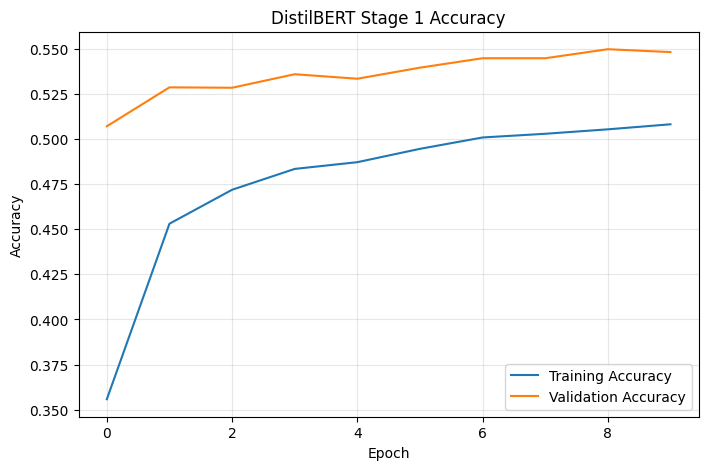

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_text_safe_stage1.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_text_safe_stage1.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DistilBERT Stage 1 Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

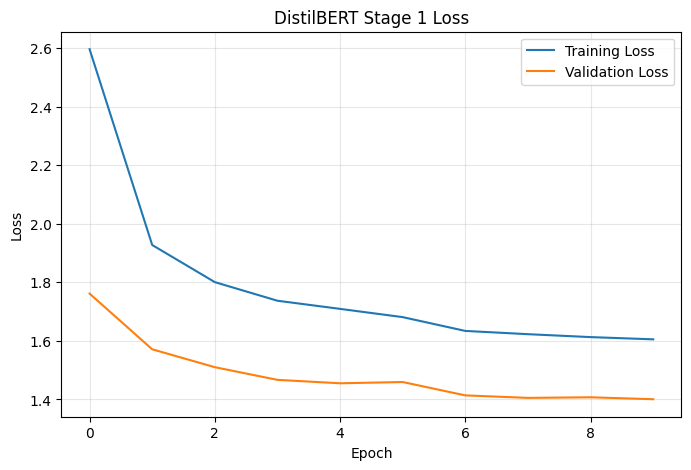

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_text_safe_stage1.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_text_safe_stage1.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT Stage 1 Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Normalized Confusion Matrix

The row-normalized confusion matrix shows how predictions are distributed for each true class.

Normalization makes the matrix easier to interpret under class imbalance because each row represents the proportion of samples from one true category. Class indices are displayed instead of all 90 class names to keep the figure readable.

276/276 [==============================] - 24s 78ms/step


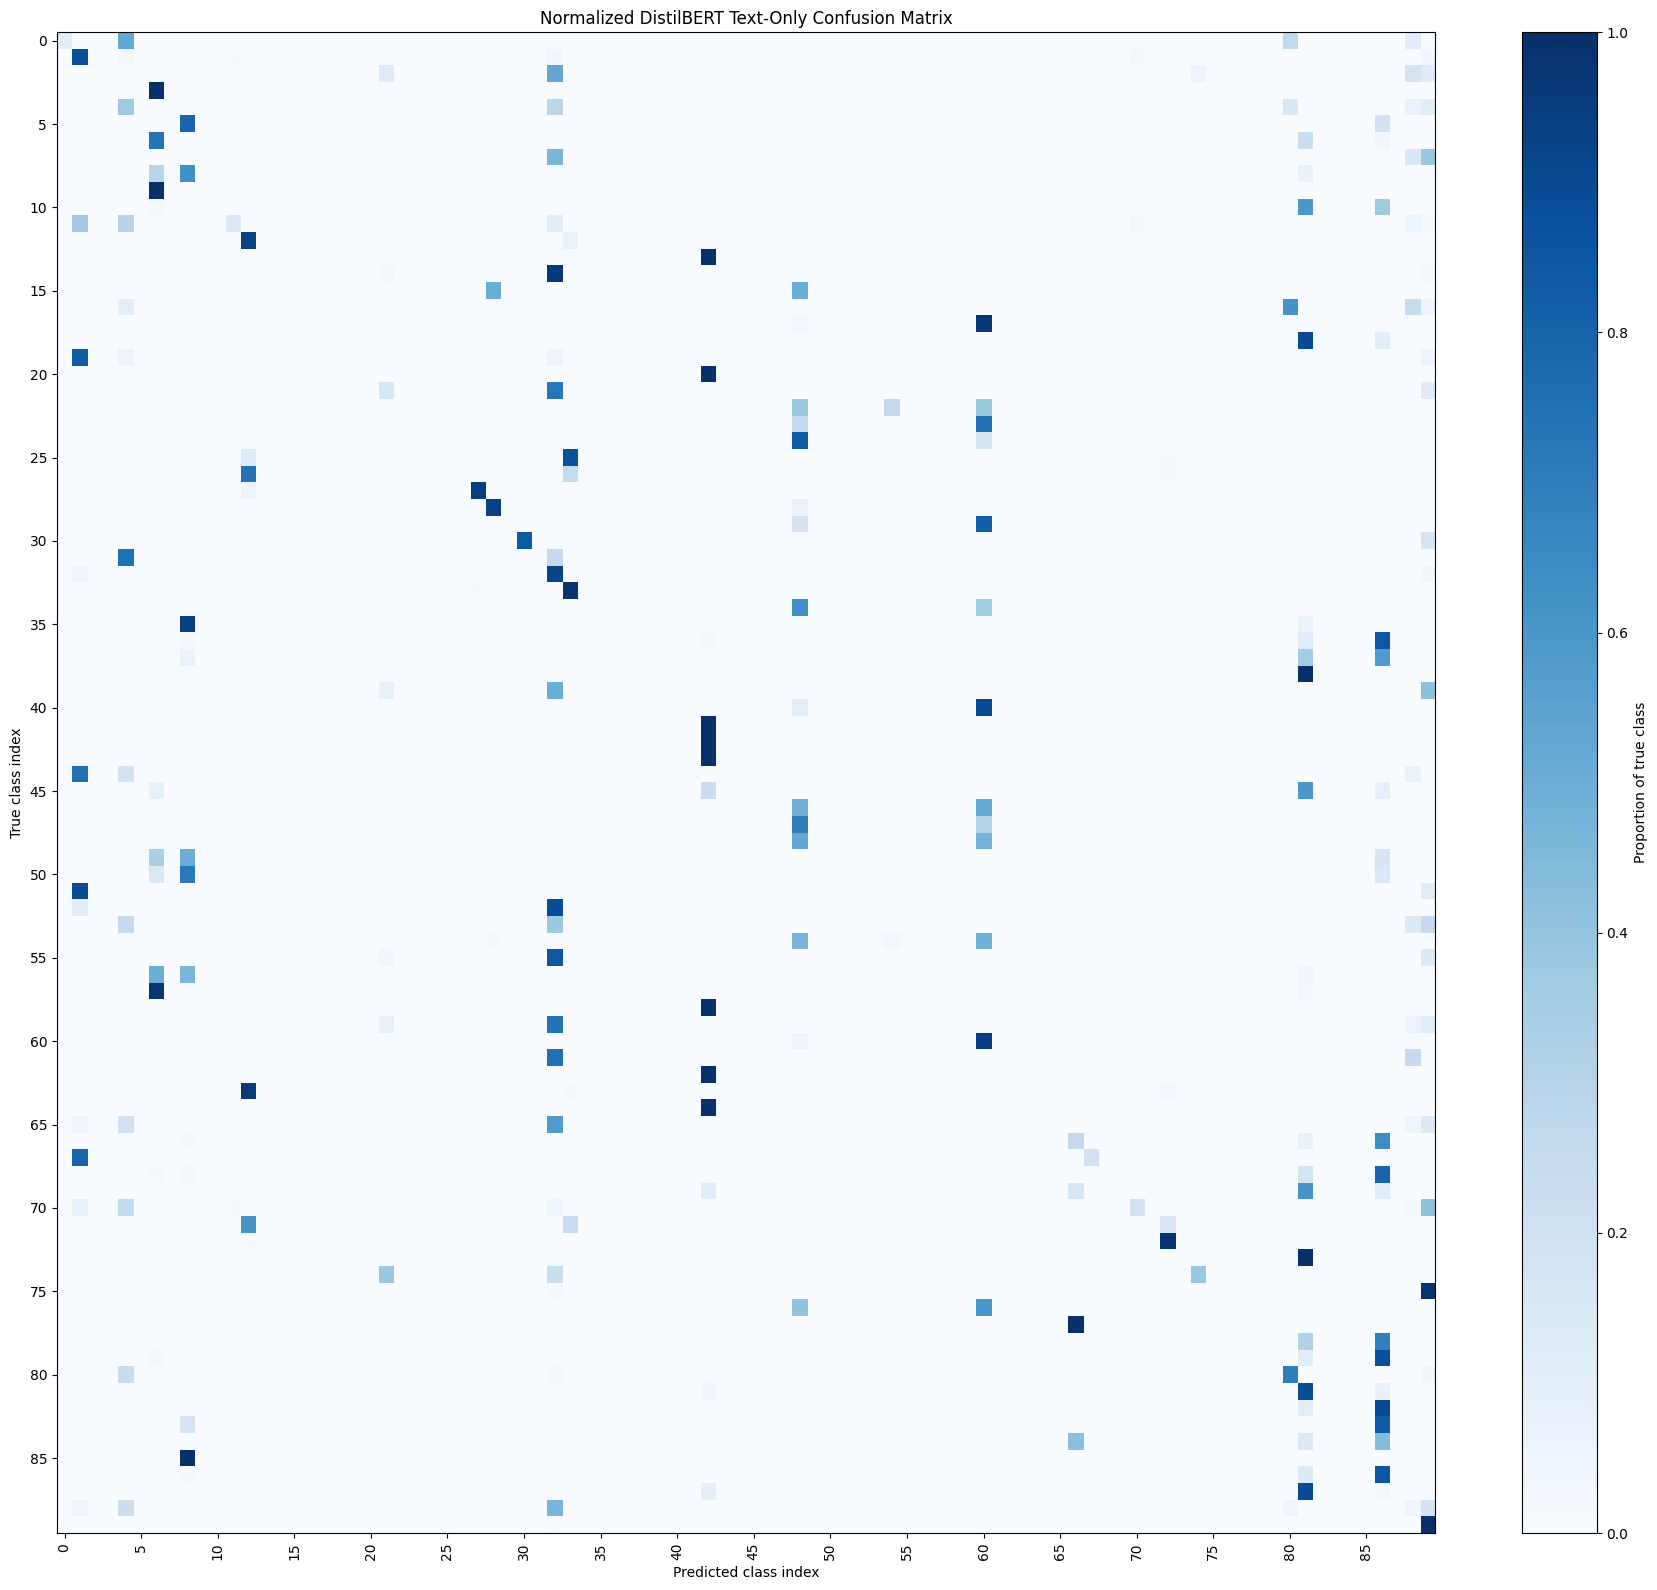

In [51]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Generate predictions
pred_probabilities = text_model_safe.predict(
    test_text_safe_ds,
    verbose=1
)

pred_labels = np.argmax(
    pred_probabilities,
    axis=1
)

true_labels = test_df["label"].to_numpy()

# Row-normalized confusion matrix
cm_normalized = confusion_matrix(
    true_labels,
    pred_labels,
    labels=np.arange(NUM_CLASSES),
    normalize="true"
)

plt.figure(figsize=(18, 16))

plt.imshow(
    cm_normalized,
    interpolation="nearest",
    cmap="Blues",
    aspect="auto"
)

plt.title("Normalized DistilBERT Text-Only Confusion Matrix")
plt.xlabel("Predicted class index")
plt.ylabel("True class index")
plt.colorbar(label="Proportion of true class")

# Showing all 90 class names would make the figure unreadable,
# so class indices are used instead.
tick_positions = np.arange(0, NUM_CLASSES, 5)

plt.xticks(tick_positions, tick_positions, rotation=90)
plt.yticks(tick_positions, tick_positions)

plt.tight_layout()
plt.show()

In [52]:
prediction_results = pd.DataFrame({
    "true_class": label_encoder.inverse_transform(true_labels),
    "predicted_class": label_encoder.inverse_transform(pred_labels)
})

prediction_results.head()

,true_class,predicted_class
0,Kurtas,Kurtas
1,Trousers,Shirts
2,Sports Shoes,Sports Shoes
3,Kurtas,Kurtas
4,Tshirts,Tshirts


### Most Common Text-Model Confusions

The most frequent errors occur between semantically or functionally related fashion categories. The DistilBERT text-only model commonly predicts:

- Shirts as Tshirts
- Tshirts as Tops
- Sandals and Flip Flops as Casual Shoes
- Flats as Heels
- Wallets and Clutches as Handbags

These errors indicate that the leakage-controlled metadata does not contain enough detail to reliably distinguish visually similar subcategories. The model also shows a tendency to predict more frequent classes, which is consistent with the class imbalance present in the dataset.

This result supports the use of multimodal fusion, where visual features from EfficientNetV2 provide the fine-grained information missing from the text representation.

In [53]:
incorrect_predictions = prediction_results[
    prediction_results["true_class"]
    != prediction_results["predicted_class"]
]

most_common_confusions = (
    incorrect_predictions
    .groupby(["true_class", "predicted_class"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(15)
)

most_common_confusions

,true_class,predicted_class,count
167,Shirts,Tshirts,414
192,Sunglasses,Watches,212
219,Tshirts,Tops,181
153,Sandals,Casual Shoes,171
72,Flip Flops,Casual Shoes,136
70,Flats,Heels,87
172,Shorts,Tshirts,87
225,Wallets,Handbags,87
157,Sarees,Kurtas,85
53,Dresses,Tops,83


### Classification Report Analysis

The DistilBERT text-only model achieved approximately **55% test accuracy** and a **45% weighted F1-score**. However, the macro F1-score was only approximately **18%**, indicating weak performance across many minority classes.

The model performed strongly for a small number of well-represented or metadata-distinct categories, including Sports Shoes, Formal Shoes, Free Gifts, Kurtas, Heels, and Watches. In contrast, many rare or semantically similar classes received zero recall because the model did not predict them correctly.

This imbalance between overall accuracy and macro-level performance shows that the leakage-controlled metadata is insufficient for reliable fine-grained classification across all 90 product categories. These limitations motivate the multimodal fusion approach, where image embeddings provide visual information that is unavailable to the text-only model.

In [54]:
from sklearn.metrics import classification_report

text_report = classification_report(
    test_df["label"],
    pred_labels,
    target_names=label_encoder.classes_,
    zero_division=0
)

print(text_report)

                        precision    recall  f1-score   support

    Accessory Gift Set       1.00      0.11      0.19        19
             Backpacks       0.57      0.88      0.69       145
                Bangle       0.00      0.00      0.00        17
             Bath Robe       0.00      0.00      0.00         4
                 Belts       0.31      0.37      0.34       163
                Boxers       0.00      0.00      0.00        10
                   Bra       0.34      0.74      0.47        95
              Bracelet       0.00      0.00      0.00        13
                Briefs       0.43      0.63      0.51       170
             Camisoles       0.00      0.00      0.00         8
                Capris       0.00      0.00      0.00        35
                  Caps       0.67      0.14      0.23        57
          Casual Shoes       0.61      0.92      0.73       569
              Churidar       0.00      0.00      0.00         6
              Clutches       0.00      

## Conclusion

A leakage-controlled DistilBERT classifier was developed for fashion product classification using product metadata only.

The model achieved approximately **55% test accuracy** across **90 fashion categories**. Performance was strongest for frequent product classes but weaker for minority and visually similar categories, resulting in a macro F1-score of approximately **18%**.

The trained DistilBERT model was subsequently converted into a text feature extractor that generates **256-dimensional embeddings**, which are combined with EfficientNetV2 image embeddings in the multimodal fusion model.